# Machine Learning-Based Forest Fire Burned Area Prediction System

## Dataset Investigation

### Objective

The objective of this notebook is to investigate the UCI Forest Fires dataset before performing any preprocessing or machine learning tasks.

The investigation includes:

- Loading the dataset
- Understanding the dataset structure
- Identifying missing values
- Identifying duplicate records
- Examining data types
- Generating descriptive statistics
- Exploring the target variable
- Understanding relationships between variables

The findings from this notebook will guide the preprocessing and model development stages.


In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Projects\Forest-Fire-Burned-Area-Prediction-System\.venv\Scripts\python.exe
3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]


In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Notebook settings
%matplotlib inline

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load dataset
df = pd.read_csv("../../dataset/forestfires.csv")

# Display first five rows
df.head()
# Dataset dimensions
print("Rows and Columns:", df.shape)
# Dataset information
df.info()
# Dataset columns
df.columns

Rows and Columns: (517, 13)
<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), str(2)
memory usage: 52.6 KB


Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'], dtype='str')

# Missing Value Analysis

Missing values can negatively affect machine learning models. Before preprocessing, we must verify whether the dataset contains any missing values.

In [7]:
# Check missing values
missing_values = df.isnull().sum()
missing_values


X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [8]:
# Total missing values
print("Total Missing Values:", missing_values.sum())

Total Missing Values: 0


### Observations

- No missing values were found.
- No imputation techniques are required.
- The dataset is complete and suitable for machine learning.

# Duplicate Record Analysis

Duplicate observations can bias machine learning models. Therefore, duplicate records must be identified.

In [9]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 4


In [10]:
df[df.duplicated()]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


### Observations

- Four duplicate records were identified in the dataset.
- The duplicate records will be retained during the investigation phase.
- A decision on whether to remove them will be made during the preprocessing stage after assessing their potential impact on model performance.

# Exploratory Data Analysis (EDA)
# Target Variable Analysis

The target variable (**area**) represents the burned area (in hectares) after a forest fire.

Understanding its distribution is essential because machine learning models can be affected by highly skewed target variables.

In [11]:
# Summary statistics of target variable
df["area"].describe()

count     517.000000
mean       12.847292
std        63.655818
min         0.000000
25%         0.000000
50%         0.520000
75%         6.570000
max      1090.840000
Name: area, dtype: float64

### Interpretation

The burned area variable exhibits a substantial difference between the mean (12.85 hectares) and the median (0.52 hectares).

This indicates that the dataset is highly positively skewed, where most forest fires burn relatively small areas while a few extreme events result in very large burned areas.

Such skewness can negatively affect regression models and should be considered during preprocessing.

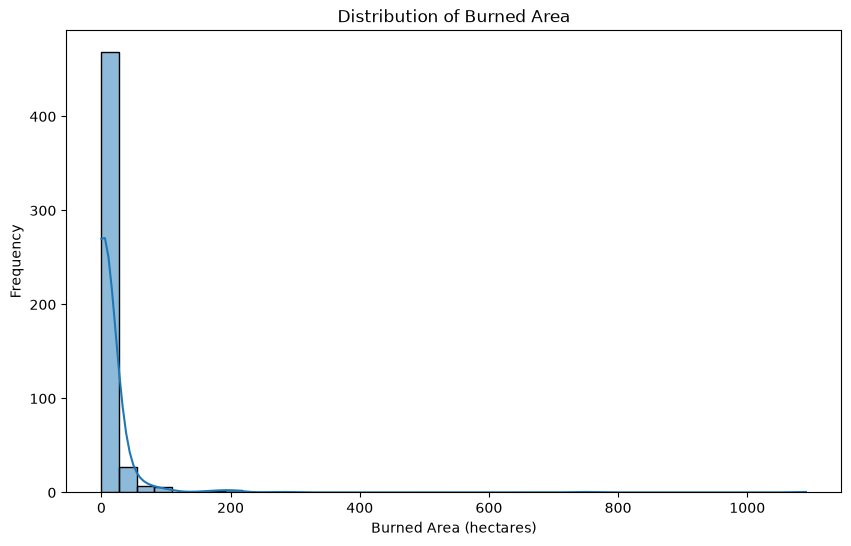

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(df["area"], bins=40, kde=True)

plt.title("Distribution of Burned Area")
plt.xlabel("Burned Area (hectares)")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Most forest fires resulted in very small burned areas.

Only a few observations correspond to extremely large fires.

The distribution is highly right-skewed.

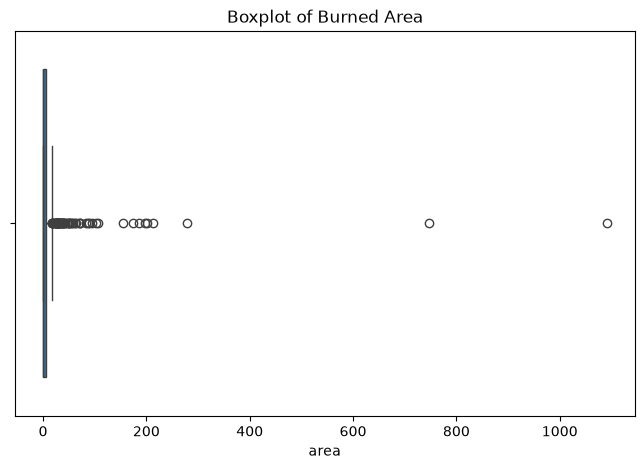

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["area"])

plt.title("Boxplot of Burned Area")

plt.show()

### Interpretation

Numerous outliers are present.

These represent genuine large wildfire events.

They should not be removed solely because they are statistical outliers.

### Conclusion

The target variable (area) exhibits a highly positively skewed distribution with several extreme observations. These values represent genuine wildfire events rather than data errors. Therefore, the target variable will be transformed using a logarithmic transformation during preprocessing instead of removing the outliers.